Train samples: 60000, Test samples: 10000
Epoch 1/10 - loss: 0.5048 - accuracy: 0.8715 - val_loss: 0.3489 - val_accuracy: 0.9054
Epoch 2/10 - loss: 0.3476 - accuracy: 0.9034 - val_loss: 0.3147 - val_accuracy: 0.9118
Epoch 3/10 - loss: 0.3224 - accuracy: 0.9101 - val_loss: 0.3013 - val_accuracy: 0.9176
Epoch 4/10 - loss: 0.3090 - accuracy: 0.9135 - val_loss: 0.2927 - val_accuracy: 0.9181
Epoch 5/10 - loss: 0.3005 - accuracy: 0.9159 - val_loss: 0.2869 - val_accuracy: 0.9202
Epoch 6/10 - loss: 0.2943 - accuracy: 0.9185 - val_loss: 0.2836 - val_accuracy: 0.9185
Epoch 7/10 - loss: 0.2894 - accuracy: 0.9193 - val_loss: 0.2808 - val_accuracy: 0.9217
Epoch 8/10 - loss: 0.2858 - accuracy: 0.9202 - val_loss: 0.2787 - val_accuracy: 0.9221
Epoch 9/10 - loss: 0.2825 - accuracy: 0.9215 - val_loss: 0.2774 - val_accuracy: 0.9213
Epoch 10/10 - loss: 0.2798 - accuracy: 0.9218 - val_loss: 0.2766 - val_accuracy: 0.9229
dict_keys(['accuracy', 'val_accuracy', 'loss', 'val_loss'])


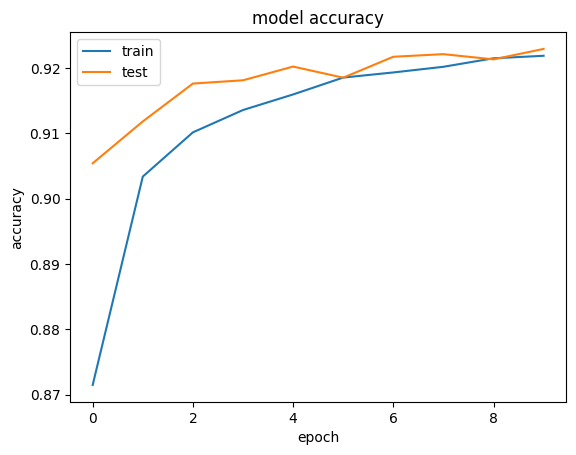

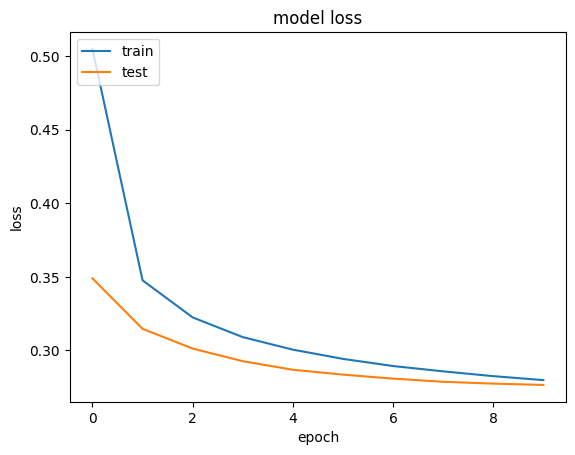

In [ ]:
# 1. SoftMax
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Load the real training and test dataset using torchvision
transform = transforms.Compose([
    transforms.ToTensor(), # Converts to [0, 1] floats
    transforms.Lambda(lambda x: torch.flatten(x)) # Flatten to 1D array of 784
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

input_shape = 28 * 28
nb_classes = 10
batch_size = 80 #160

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# The Sequential model is a linear stack of layers
# Note: Softmax is omitted here because PyTorch's CrossEntropyLoss intrinsically applies LogSoftmax.
model = nn.Sequential(
    nn.Linear(input_shape, nb_classes)
)

# Before training a model, configure the learning process
# using the cross-entropy loss function (objective)
# PyTorch's CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss(),
# so we don't need an explicit Softmax layer in the model.
criterion = nn.CrossEntropyLoss()

# using the stochastic gradient descent (SGD)
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 10 epochs is enough for the real MNIST dataset
epochs = 10

# Dictionary to store metrics
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

# fit the model, the training process
for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()           # clear the gradients
        outputs = model(inputs)         # forward pass
        loss = criterion(outputs, labels) # calculate loss
        loss.backward()                 # backward pass
        optimizer.step()                # update weights

        # Track accuracy and loss
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad(): # Disable gradients during validation
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    # Save to history dict
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}")

# list all data in history
print(history.keys())

plt.figure(1)
# summarize history for accuracy
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show(block=False)

plt.figure(2)
# summarize history for loss
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show(block=True)


Train samples: 60000, Test samples: 10000
Epoch 1/10 - loss: 1.6074 - accuracy: 0.4569 - val_loss: 0.4778 - val_accuracy: 0.8573
Epoch 2/10 - loss: 0.3689 - accuracy: 0.8894 - val_loss: 0.2476 - val_accuracy: 0.9254
Epoch 3/10 - loss: 0.2074 - accuracy: 0.9389 - val_loss: 0.1592 - val_accuracy: 0.9533
Epoch 4/10 - loss: 0.1462 - accuracy: 0.9566 - val_loss: 0.1242 - val_accuracy: 0.9625
Epoch 5/10 - loss: 0.1140 - accuracy: 0.9666 - val_loss: 0.1136 - val_accuracy: 0.9669
Epoch 6/10 - loss: 0.0933 - accuracy: 0.9728 - val_loss: 0.1000 - val_accuracy: 0.9683
Epoch 7/10 - loss: 0.0779 - accuracy: 0.9763 - val_loss: 0.0956 - val_accuracy: 0.9702
Epoch 8/10 - loss: 0.0653 - accuracy: 0.9802 - val_loss: 0.0895 - val_accuracy: 0.9720
Epoch 9/10 - loss: 0.0560 - accuracy: 0.9825 - val_loss: 0.0905 - val_accuracy: 0.9726
Epoch 10/10 - loss: 0.0467 - accuracy: 0.9858 - val_loss: 0.0889 - val_accuracy: 0.9738
dict_keys(['accuracy', 'val_accuracy', 'loss', 'val_loss'])


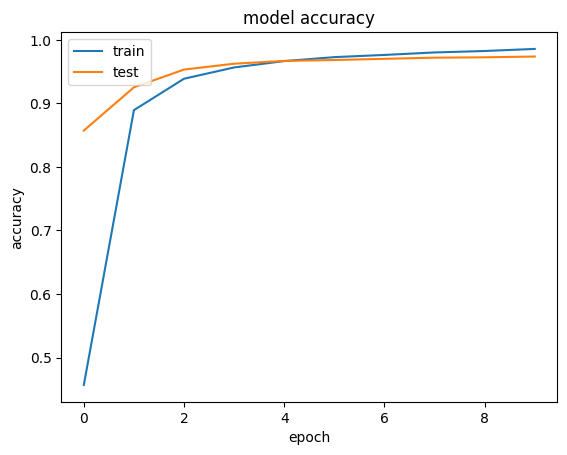

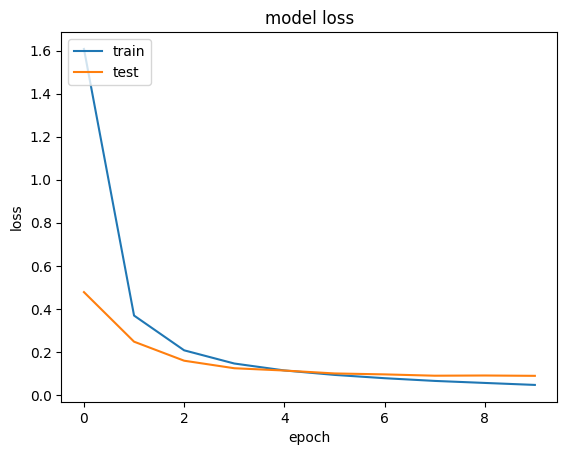

In [ ]:
# 2. Add more fully connected layers
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Load the real training and test dataset using torchvision
transform = transforms.Compose([
    transforms.ToTensor(), # Converts to [0, 1] floats
    transforms.Lambda(lambda x: torch.flatten(x)) # Flatten to 1D array of 784
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

input_shape = 28 * 28
nb_classes = 10
batch_size = 160

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# The Sequential model is a linear stack of layers
# Note: Softmax is omitted here because PyTorch's CrossEntropyLoss intrinsically applies LogSoftmax.
model = nn.Sequential(
    nn.Linear(input_shape, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 60),
    nn.ReLU(),
    nn.Linear(60, 30),
    nn.ReLU(),
    nn.Linear(30, nb_classes)
)

# Before training a model, configure the learning process
# using the cross-entropy loss function (objective)
# PyTorch's CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss(),
# so we don't need an explicit Softmax layer in the model.
criterion = nn.CrossEntropyLoss()

# using the stochastic gradient descent (SGD)
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 10 epochs is enough for the real MNIST dataset
epochs = 10

# Dictionary to store metrics
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

# fit the model, the training process
for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()           # clear the gradients
        outputs = model(inputs)         # forward pass
        loss = criterion(outputs, labels) # calculate loss
        loss.backward()                 # backward pass
        optimizer.step()                # update weights

        # Track accuracy and loss
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad(): # Disable gradients during validation
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    # Save to history dict
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}")

# list all data in history
print(history.keys())

plt.figure(1)
# summarize history for accuracy
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show(block=False)

plt.figure(2)
# summarize history for loss
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show(block=True)
